# SUBFASE 3: EDA Multihorizonte para Clasificacion Direccional (SVC)

Objetivo de la subfase:
- Justificar con evidencia la dificultad y pertinencia de cada horizonte (h=1, h=5, h=20).
- Mantener comparacion consistente entre horizontes usando el mismo protocolo descriptivo.

In [1]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 220)
pd.set_option('display.width', 260)
sns.set_theme(style='whitegrid')

In [2]:
# Configuracion base
INPUT_PATH = Path('../data/processed/BVG_Acciones_limpio.csv')

empresas_objetivo = ['CORPORACION FAVORITA C.A.', 'BANCO GUAYAQUIL S.A.']
emisor_col = 'EMISOR'
fecha_col = 'FECHA NEGOCIACIÓN'
precio_col = 'PRECIO'
HORIZONS = [1, 5, 20]

In [3]:
df = pd.read_csv(INPUT_PATH)
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce')
df = df.dropna(subset=[fecha_col, precio_col, emisor_col]).copy()

print('Shape filtrado:', df.shape)
print('Rango fechas:', df[fecha_col].min(), '->', df[fecha_col].max())
display(df[[fecha_col, emisor_col, precio_col]].head())

Shape filtrado: (18188, 11)
Rango fechas: 2019-01-02 00:00:00 -> 2026-03-25 00:00:00


,FECHA NEGOCIACIÓN,EMISOR,PRECIO
0,2019-01-02,BANCO GUAYAQUIL S.A.,0.96
1,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
2,2019-01-03,BANCO GUAYAQUIL S.A.,0.96
3,2019-01-14,BANCO GUAYAQUIL S.A.,0.96
4,2019-01-14,BANCO GUAYAQUIL S.A.,0.95


In [4]:
def build_trade_day_panel(df_input: pd.DataFrame) -> pd.DataFrame:
    """Consolida precios por dia de trading y emisor en formato ancho."""
    serie = (
        df_input.groupby([fecha_col, emisor_col], as_index=False)[precio_col]
        .last()
        .pivot(index=fecha_col, columns=emisor_col, values=precio_col)
        .sort_index()
    )
    return serie

serie_precios = build_trade_day_panel(df)
display(serie_precios.head())
display(serie_precios.describe().T)

EMISOR,BANCO GUAYAQUIL S.A.,CORPORACION FAVORITA C.A.
FECHA NEGOCIACIÓN,,
2019-01-02,0.96,2.44
2019-01-03,0.96,2.45
2019-01-04,NaN,2.44
2019-01-07,NaN,2.45
2019-01-09,NaN,2.45


,count,mean,std,min,25%,50%,75%,max
EMISOR,,,,,,,,
BANCO GUAYAQUIL S.A.,1168.0,1.086644,0.299380,0.74,0.900,1.00,1.10,2.30
CORPORACION FAVORITA C.A.,1703.0,2.129918,0.282684,1.57,1.875,2.17,2.38,2.81


In [5]:
def build_event_returns(serie_panel: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for empresa in empresas_objetivo:
        d = (
            serie_panel[empresa]
            .dropna()
            .to_frame('precio_trade_day')
            .reset_index()
            .rename(columns={fecha_col: 'fecha'})
            .sort_values('fecha')
            .reset_index(drop=True)
        )
        d['empresa'] = empresa
        d['ret'] = np.log(d['precio_trade_day'] / d['precio_trade_day'].shift(1))
        d['delta_t'] = d['fecha'].diff().dt.days
        rows.append(d)
    return pd.concat(rows, ignore_index=True)

def build_multihorizon_targets(df_ret_input: pd.DataFrame, horizons: list[int]) -> pd.DataFrame:
    rows = []
    for empresa in empresas_objetivo:
        d = (
            df_ret_input[df_ret_input['empresa'] == empresa][['fecha', 'precio_trade_day']]
            .dropna()
            .sort_values('fecha')
            .reset_index(drop=True)
        )
        for h in horizons:
            tmp = d.copy()
            tmp['empresa'] = empresa
            tmp['horizon'] = h
            tmp['ret_fwd_h'] = np.log(tmp['precio_trade_day'].shift(-h) / tmp['precio_trade_day'])
            tmp['target_up_h'] = np.where(
                tmp['ret_fwd_h'].notna(),
                (tmp['ret_fwd_h'] > 0).astype(int),
                np.nan
            )
            tmp['delta_cal_t_to_t_h'] = (tmp['fecha'].shift(-h) - tmp['fecha']).dt.days
            rows.append(tmp[['empresa', 'fecha', 'horizon', 'precio_trade_day', 'ret_fwd_h', 'target_up_h', 'delta_cal_t_to_t_h']])
    return pd.concat(rows, ignore_index=True)

df_ret = build_event_returns(serie_precios)
df_h = build_multihorizon_targets(df_ret, HORIZONS)

print('df_ret shape:', df_ret.shape)
print('df_h shape:', df_h.shape)
display(df_ret.head())
display(df_h.head())

df_ret shape: (2871, 5)
df_h shape: (8613, 7)


,fecha,precio_trade_day,empresa,ret,delta_t
0,2019-01-02,2.44,CORPORACION FAVORITA C.A.,NaN,NaN
1,2019-01-03,2.45,CORPORACION FAVORITA C.A.,0.00409,1.0
2,2019-01-04,2.44,CORPORACION FAVORITA C.A.,-0.00409,1.0
3,2019-01-07,2.45,CORPORACION FAVORITA C.A.,0.00409,3.0
4,2019-01-09,2.45,CORPORACION FAVORITA C.A.,0.00000,2.0


,empresa,fecha,horizon,precio_trade_day,ret_fwd_h,target_up_h,delta_cal_t_to_t_h
0,CORPORACION FAVORITA C.A.,2019-01-02,1,2.44,0.004090,1.0,1.0
1,CORPORACION FAVORITA C.A.,2019-01-03,1,2.45,-0.004090,0.0,1.0
2,CORPORACION FAVORITA C.A.,2019-01-04,1,2.44,0.004090,1.0,3.0
3,CORPORACION FAVORITA C.A.,2019-01-07,1,2.45,0.000000,0.0,2.0
4,CORPORACION FAVORITA C.A.,2019-01-09,1,2.45,0.016195,1.0,1.0


## Calidad de muestra para clasificacion
Se cuantifica densidad de eventos, irregularidad temporal y tamano de muestra efectivo por emisor.

- `mean_delta_t_days`: separacion promedio en dias calendario entre dos eventos consecutivos de trading.
- `p90_delta_t_days`: percentil 90 de esa separacion; es decir, el 90% de los saltos de tiempo son menores o iguales a ese valor, y el 10% son mas largos.

In [6]:
rows = []
for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].sort_values('fecha').copy()

    n_ret = int(d['ret'].notna().sum())
    n_trade_days = int(d['precio_trade_day'].notna().sum())
    fecha_min = d['fecha'].min()
    fecha_max = d['fecha'].max()
    span_days = int((fecha_max - fecha_min).days) + 1 if pd.notna(fecha_min) and pd.notna(fecha_max) else np.nan
    densidad = (n_trade_days / span_days) if span_days and span_days > 0 else np.nan

    dt = d['delta_t'].dropna()
    mean_dt = float(dt.mean()) if len(dt) > 0 else np.nan
    p90_dt = float(dt.quantile(0.90)) if len(dt) > 0 else np.nan

    rows.append({
        'empresa': empresa,
        'n_ret': n_ret,
        'n_trade_days': n_trade_days,
        'densidad_eventos': densidad,
        'mean_delta_t_days': mean_dt,
        'p90_delta_t_days': p90_dt
    })

muestra_df = pd.DataFrame(rows)
display(muestra_df)

,empresa,n_ret,n_trade_days,densidad_eventos,mean_delta_t_days,p90_delta_t_days
0,CORPORACION FAVORITA C.A.,1702,1703,0.645076,1.550529,3.0
1,BANCO GUAYAQUIL S.A.,1167,1168,0.442424,2.261354,5.0


## Distribucion de retornos
Se evalua forma de distribucion (media, dispersion, sesgo, curtosis) para anticipar dificultad de separacion en SVC.

In [7]:
stats_rows = []

for empresa in empresas_objetivo:
    d = df_ret[df_ret['empresa'] == empresa].copy()
    s = d['ret'].dropna()

    stats_rows.append({
        'empresa': empresa,
        'n': int(len(s)),
        'mean': float(s.mean()) if len(s) > 0 else np.nan,
        'std': float(s.std()) if len(s) > 0 else np.nan,
        'skew': float(s.skew()) if len(s) > 0 else np.nan,
        'kurtosis': float(s.kurtosis()) if len(s) > 0 else np.nan,
    })

stats_ret_df = pd.DataFrame(stats_rows).sort_values('empresa').reset_index(drop=True)
display(stats_ret_df)

,empresa,n,mean,std,skew,kurtosis
0,BANCO GUAYAQUIL S.A.,1167,0.000741,0.031253,0.052901,16.825374
1,CORPORACION FAVORITA C.A.,1702,-0.000117,0.015461,-0.956412,25.656450


In [8]:
# Control metodologico: proporcion de retornos cero por horizonte
for h in HORIZONS:
    print(f'\nRetornos de 0 - h={h}')
    for emisor in empresas_objetivo:
        s = df_h[(df_h['empresa'] == emisor) & (df_h['horizon'] == h)]['ret_fwd_h'].dropna()
        pct_zero = (s.eq(0).mean() * 100) if len(s) > 0 else np.nan
        print(f'  {emisor}: {pct_zero:.2f}%')



Retornos de 0 - h=1
  CORPORACION FAVORITA C.A.: 35.49%
  BANCO GUAYAQUIL S.A.: 38.56%

Retornos de 0 - h=5
  CORPORACION FAVORITA C.A.: 21.97%
  BANCO GUAYAQUIL S.A.: 24.94%

Retornos de 0 - h=20
  CORPORACION FAVORITA C.A.: 8.38%
  BANCO GUAYAQUIL S.A.: 12.98%


## Comparaciones por horizonte
Se compara balance de clases, dispersion, colas y conversion a dias calendario para cada horizonte y emisor.
 `delta_cal_p90_days`:
- Percentil 90 de los dias calendario entre `t` y `t+h` para cada horizonte.
- Mide la latencia operativa en escenarios menos frecuentes pero relevantes (cola alta de espera temporal).

In [9]:
h_summary_rows = []

for empresa in empresas_objetivo:
    for h in HORIZONS:
        d = df_h[(df_h['empresa'] == empresa) & (df_h['horizon'] == h)].copy()
        d = d[d['ret_fwd_h'].notna()].copy()

        y = d['target_up_h']
        r = d['ret_fwd_h']
        dt = d['delta_cal_t_to_t_h']

        p_up = float((y == 1).mean()) if len(y) > 0 else np.nan
        p_down = 1.0 - p_up if pd.notna(p_up) else np.nan
        imbalance = abs(p_up - 0.5) if pd.notna(p_up) else np.nan

        q20_abs = float(r.abs().quantile(0.20)) if len(r) > 0 else np.nan
        frac_low_signal = float((r.abs() <= q20_abs).mean()) if pd.notna(q20_abs) else np.nan

        h_summary_rows.append({
            'empresa': empresa,
            'horizon': h,
            'n_valid': int(len(d)),
            'p_up': p_up,
            'p_down': p_down,
            'class_imbalance_abs': imbalance,
            'ret_std': float(r.std()) if len(r) > 0 else np.nan,
            'ret_kurtosis': float(r.kurtosis()) if len(r) > 0 else np.nan,
            'frac_low_signal_labels': frac_low_signal,
            'delta_cal_median_days': float(dt.median()) if len(dt) > 0 else np.nan,
            'delta_cal_p90_days': float(dt.quantile(0.90)) if len(dt) > 0 else np.nan
        })

h_summary_df = pd.DataFrame(h_summary_rows).sort_values(['empresa', 'horizon']).reset_index(drop=True)

balance_pre_df = h_summary_df[[
    'empresa', 'horizon', 'n_valid', 'p_up', 'p_down', 'class_imbalance_abs'
 ]].copy()

display(balance_pre_df)
display(h_summary_df)

,empresa,horizon,n_valid,p_up,p_down,class_imbalance_abs
0,BANCO GUAYAQUIL S.A.,1,1167,0.324764,0.675236,0.175236
1,BANCO GUAYAQUIL S.A.,5,1163,0.442820,0.557180,0.057180
2,BANCO GUAYAQUIL S.A.,20,1148,0.530488,0.469512,0.030488
3,CORPORACION FAVORITA C.A.,1,1702,0.319624,0.680376,0.180376
4,CORPORACION FAVORITA C.A.,5,1698,0.369847,0.630153,0.130153
5,CORPORACION FAVORITA C.A.,20,1683,0.418301,0.581699,0.081699


,empresa,horizon,n_valid,p_up,p_down,class_imbalance_abs,ret_std,ret_kurtosis,frac_low_signal_labels,delta_cal_median_days,delta_cal_p90_days
0,BANCO GUAYAQUIL S.A.,1,1167,0.324764,0.675236,0.175236,0.031253,16.825374,0.385604,1.0,5.0
1,BANCO GUAYAQUIL S.A.,5,1163,0.442820,0.557180,0.057180,0.041125,8.731183,0.249355,10.0,16.8
2,BANCO GUAYAQUIL S.A.,20,1148,0.530488,0.469512,0.030488,0.074638,2.003971,0.202962,41.0,63.0
3,CORPORACION FAVORITA C.A.,1,1702,0.319624,0.680376,0.180376,0.015461,25.656450,0.354877,1.0,3.0
4,CORPORACION FAVORITA C.A.,5,1698,0.369847,0.630153,0.130153,0.024904,18.173128,0.219670,7.0,10.0
5,CORPORACION FAVORITA C.A.,20,1683,0.418301,0.581699,0.081699,0.043102,3.215863,0.203209,30.0,35.0


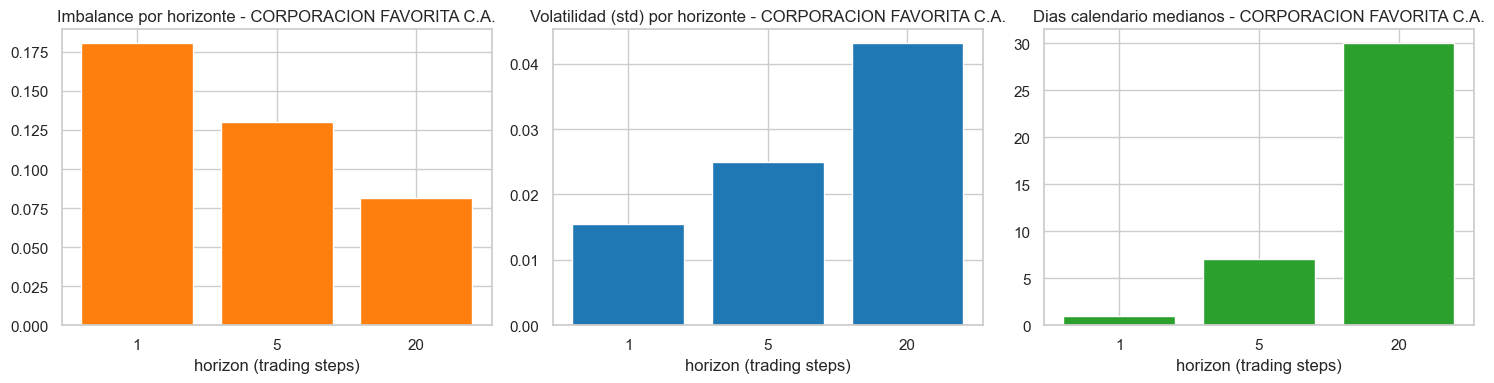

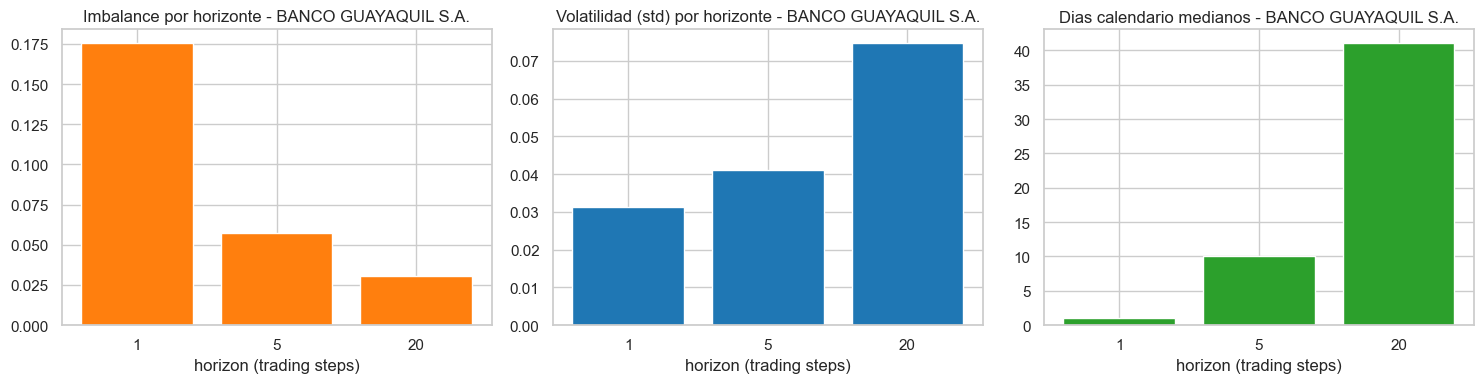

In [10]:
# Visual comparativo
for empresa in empresas_objetivo:
    s = h_summary_df[h_summary_df['empresa'] == empresa].sort_values('horizon').copy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(s['horizon'].astype(str), s['class_imbalance_abs'], color='tab:orange')
    axes[0].set_title(f'Imbalance por horizonte - {empresa}')

    axes[1].bar(s['horizon'].astype(str), s['ret_std'], color='tab:blue')
    axes[1].set_title(f'Volatilidad (std) por horizonte - {empresa}')

    axes[2].bar(s['horizon'].astype(str), s['delta_cal_median_days'], color='tab:green')
    axes[2].set_title(f'Dias calendario medianos - {empresa}')

    for ax in axes:
        ax.set_xlabel('horizon (trading steps)')

    plt.tight_layout()
    plt.show()

## Conclusiones de subfase

  - CORPORACION FAVORITA C.A.: `n_ret=1702`, `densidad_eventos=0.645`, `p90_delta_t=3` dias.
  - BANCO GUAYAQUIL S.A.: `n_ret=1167`, `densidad_eventos=0.442`, `p90_delta_t=5` dias.
- Los retornos mantienen colas pesadas, especialmente en horizontes cortos:
- Favorita: `kurtosis ret_event=29.01`.
- Banco Guayaquil: `kurtosis ret_event=14.36`.

- En comparacion multihorizonte (`h=1, 5, 20`) se observa un patron estable:
- A mayor horizonte, menor desbalance de clases (`class_imbalance_abs` baja).
- A mayor horizonte, menor curtosis del retorno futuro (`ret_kurtosis` baja).
- A mayor horizonte, mayor dispersion (`ret_std` sube) y mayor desfase calendario (`delta_cal_median_days` sube fuerte).

### Observaciones de horizontes

- `h=1` conserva mayor cercania temporal (mediana calendario = 1 dia), pero con mayor desbalance y colas mas extremas.
- `h=5` actua como punto intermedio: reduce ruido extremo frente a `h=1` sin llegar al desfase calendario tan alto de `h=20`.
- `h=20` mejora balance y forma de distribucion, pero introduce una latencia operacional alta (30-41 dias medianos, hasta 63 dias en p90 para Banco).
